Dataset Loaded: 2823 rows, 25 columns

Missing Data Report (%):
 ADDRESSLINE2    89.302161
STATE           52.639036
POSTALCODE       2.692171
TERRITORY       38.044633
dtype: float64


/tmp/ipykernel_1383/1003418397.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analysis.index, y=analysis['sum'], palette="viridis")



Visual Insights Exported Successfully.

Final Business Metrics:
                          sum         mean  count
PRODUCTLINE                                     
Classic Cars      3919615.66  4053.377104    967
Vintage Cars      1903150.84  3135.339110    607
Motorcycles       1166388.34  3523.831843    331
Trucks and Buses  1127789.84  3746.810100    301
Planes             975003.57  3186.286176    306
Ships              714437.13  3053.150128    234
Trains             226243.47  2938.226883     77


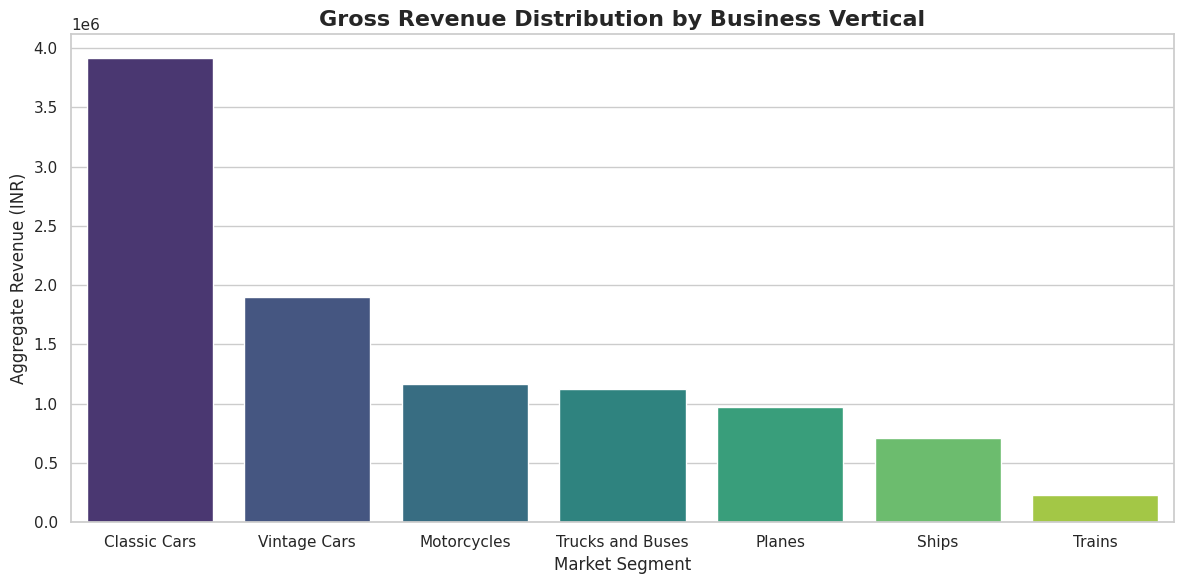

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION & STYLING ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def load_and_audit_data(file_path):
    """Loads data and performs a high-level integrity audit."""
    df = pd.read_csv(file_path, encoding='latin1')
    print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    # Identify missingness percentage per column
    null_report = df.isnull().mean() * 100
    print("\nMissing Data Report (%):\n", null_report[null_report > 0])
    return df

def clean_transaction_data(df):
    """Standardizes types and handles anomalies."""
    # Convert dates to datetime objects for time-series analysis
    df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

    # Remove negative or zero-value transactions (Data anomalies)
    df = df[df['SALES'] > 0]

    # Fill missing categories with 'Uncategorized'
    df['PRODUCTLINE'] = df['PRODUCTLINE'].fillna('Other')
    return df

def generate_revenue_insights(df):
    """Calculates KPIs and generates executive-level visuals."""
    # Grouping by Category and calculating Sum and Average
    analysis = df.groupby('PRODUCTLINE')['SALES'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

    # Visualization: Revenue Distribution
    plt.figure()
    sns.barplot(x=analysis.index, y=analysis['sum'], hue=analysis.index, palette="viridis", legend=False)
    plt.title('Gross Revenue Distribution by Business Vertical', fontsize=16, fontweight='bold')
    plt.ylabel('Aggregate Revenue (INR)', fontsize=12)
    plt.xlabel('Market Segment', fontsize=12)

    # Save the output for the Portfolio Website
    plt.tight_layout()
    plt.savefig('executive_revenue_report.png', dpi=300)
    print("\nVisual Insights Exported Successfully.")
    return analysis

# --- EXECUTION PIPELINE ---
if __name__ == "__main__":
    # 1. Extraction
    raw_data = load_and_audit_data('sales_data_sample.csv')

    # 2. Transformation
    clean_data = clean_transaction_data(raw_data)

    # 3. Analysis & Reporting
    final_metrics = generate_revenue_insights(clean_data)
    print("\nFinal Business Metrics:\n", final_metrics)